In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np 
import pandas as pd 
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision
import os

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
img_size = 64
num_epochs = 2 #50
learning_rate = 3e-4
num_channels = 3
z_dim = 100

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
transformer = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5 for _ in range(num_channels)], std = [0.5 for _ in range(num_channels)])
])

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
dataset = ImageFolder(root = "data_small/celeba_hq_256", 
                      transform = transformer)

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
train_dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)
train_dataloader

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
def initialize_weights(model):
    # Initializes weights according to the DCGAN paper
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
class Generator(nn.Module):
    def __init__(self, z_dim, num_channels):
        super(Generator,self).__init__()
        self.gen = nn.Sequential(
            self._block(z_dim,1024,1,0,4),
            self._block(1024, 512,2,0,2),
            self._block(512, 256,2,0,2),
            self._block(256, 128,2,0,2),
            nn.ConvTranspose2d(in_channels = 128, 
                           out_channels = num_channels, 
                           stride = 2, 
                           kernel_size = 2,
                           padding = 0),
            nn.Tanh()
        )
    def _block(self,in_channels, out_channels, stride, padding, kernel_size):
        block = nn.Sequential(
            nn.ConvTranspose2d(in_channels = in_channels, 
                           out_channels = out_channels, 
                           kernel_size = kernel_size,
                           stride = stride, 
                           padding = padding,
                              bias = False),
            nn.LeakyReLU(0.2)
        )
        return block
    
    def forward(self,x):
        return self.gen(x)

class Dis(nn.Module):
    def __init__(self,num_channels):
        super(Dis,self).__init__()
        self.dis = nn.Sequential(
            self._block(num_channels, 64,2,1,4),
            self._block(64, 128,2,0,2),
            self._block(128,256 ,2,0,2),
            self._block(256,512 ,2,0,2),
            nn.Conv2d(64 * 8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid(),
        )
        pass
    def _block(self,in_channels, out_channels, stride, padding, kernel_size):
        block = nn.Sequential(
            nn.Conv2d(in_channels = in_channels, 
                           out_channels = out_channels, 
                           stride = stride, 
                           padding = padding,
                     kernel_size=kernel_size,
                     bias = False),
#             nn.BatchNormalization(),
            nn.LeakyReLU(0.2)
        )
        return block
    
    def forward(self,x):
        return self.dis(x)
    
gen = Generator(100,3).to(device)
disc = Dis(3).to(device)
# print(summary(disc, input_size=[1, 3, 64, 64]))
# summary(gen, input_size=[1, 100, 1, 1])

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 2e-4  # could also use two lrs, one for gen and one for disc
BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS_IMG = 1
NOISE_DIM = 100
NUM_EPOCHS = 2 #30
FEATURES_DISC = 64
FEATURES_GEN = 64

initialize_weights(gen)
initialize_weights(disc)
opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(32, NOISE_DIM, 1, 1).to(device)
writer_real = SummaryWriter(f"logs/real")
writer_fake = SummaryWriter(f"logs/fake")
step = 0
gen.train()
disc.train()

for epoch in range(NUM_EPOCHS):
    # Target labels not needed! <3 unsupervised
    for batch_idx, (real, _) in enumerate(train_dataloader):
        real = real.to(device)
        noise = torch.randn(BATCH_SIZE, NOISE_DIM, 1, 1).to(device)
        fake = gen(noise)

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        disc_real = disc(real).reshape(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc(fake.detach()).reshape(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        ### Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z))
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        # Print losses occasionally and print to tensorboard
        if batch_idx % 500 == 0:
            print(
                f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(train_dataloader)} \
                  Loss D: {loss_disc:.4f}, loss G: {loss_gen:.4f}"
            )

            with torch.no_grad():
                fake = gen(fixed_noise)
                # take out (up to) 32 examples
                img_grid_real = torchvision.utils.make_grid(real[:32], normalize=True)
                img_grid_fake = torchvision.utils.make_grid(fake[:32], normalize=True)

                writer_real.add_image("Real", img_grid_real, global_step=step)
                writer_fake.add_image("Fake", img_grid_fake, global_step=step)

            step += 1

Epoch [0/2] Batch 0/5                   Loss D: 0.6931, loss G: 0.6956
Epoch [1/2] Batch 0/5                   Loss D: 0.6568, loss G: 0.6849


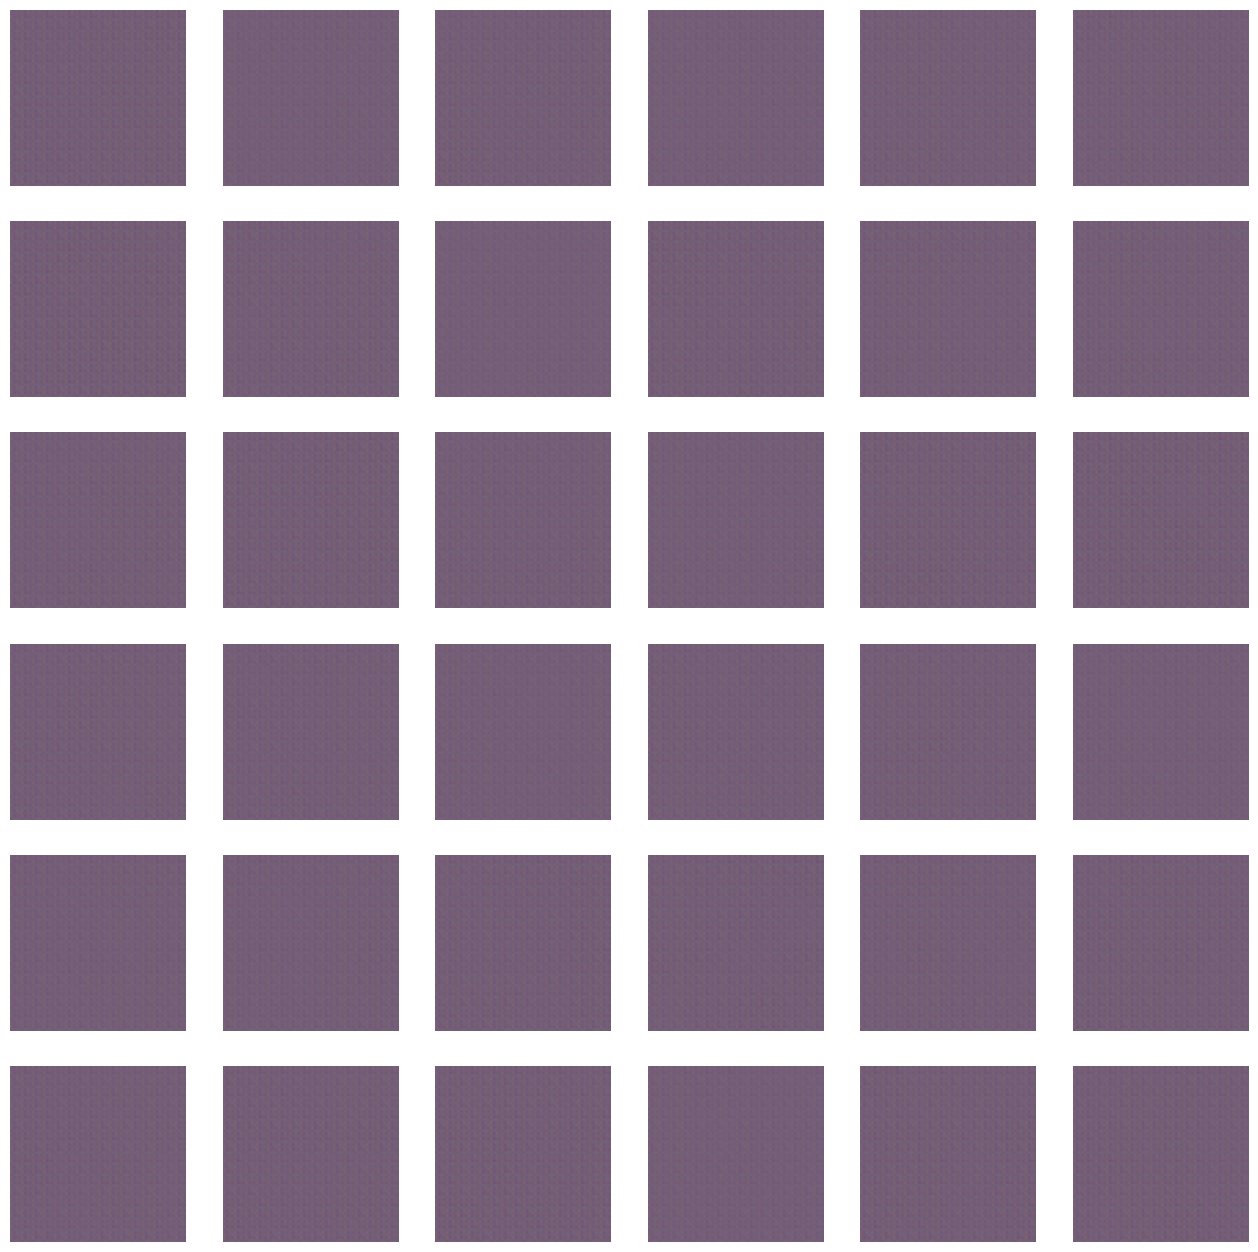

In [9]:
# --- [CELL 8]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
# === BEFORE (original) ===
# import matplotlib.pyplot as plt 
# def visual():
#     n=6
#     k=0
#     z = torch.randn((16, 100, 1, 1)).to(device)
#     out= gen(z)
#     plt.figure(figsize=(16,16))
#     out = out.cpu()
#     out = out.detach().numpy()
#     for i in range(n):
#         for j in range(n):
#             ax=plt.subplot(n,n,k+1)
#             img = (out[k]+1)/2
#             img = np.transpose(img,(1,2,0))
#             plt.imshow(img)
#             plt.axis('off')
#             k+=1
# visual()

# === AFTER (edited) ===
import matplotlib.pyplot as plt
def visual():
    n=6
    k=0
    z = torch.randn((n*n, 100, 1, 1)).to(device)
    out= gen(z)
    plt.figure(figsize=(16,16))
    out = out.cpu()
    out = out.detach().numpy()
    for i in range(n):
        for j in range(n):
            ax=plt.subplot(n,n,k+1)
            img = (out[k]+1)/2
            img = np.transpose(img,(1,2,0))
            plt.imshow(img)
            plt.axis('off')
            k+=1
visual()

AssertionError: 

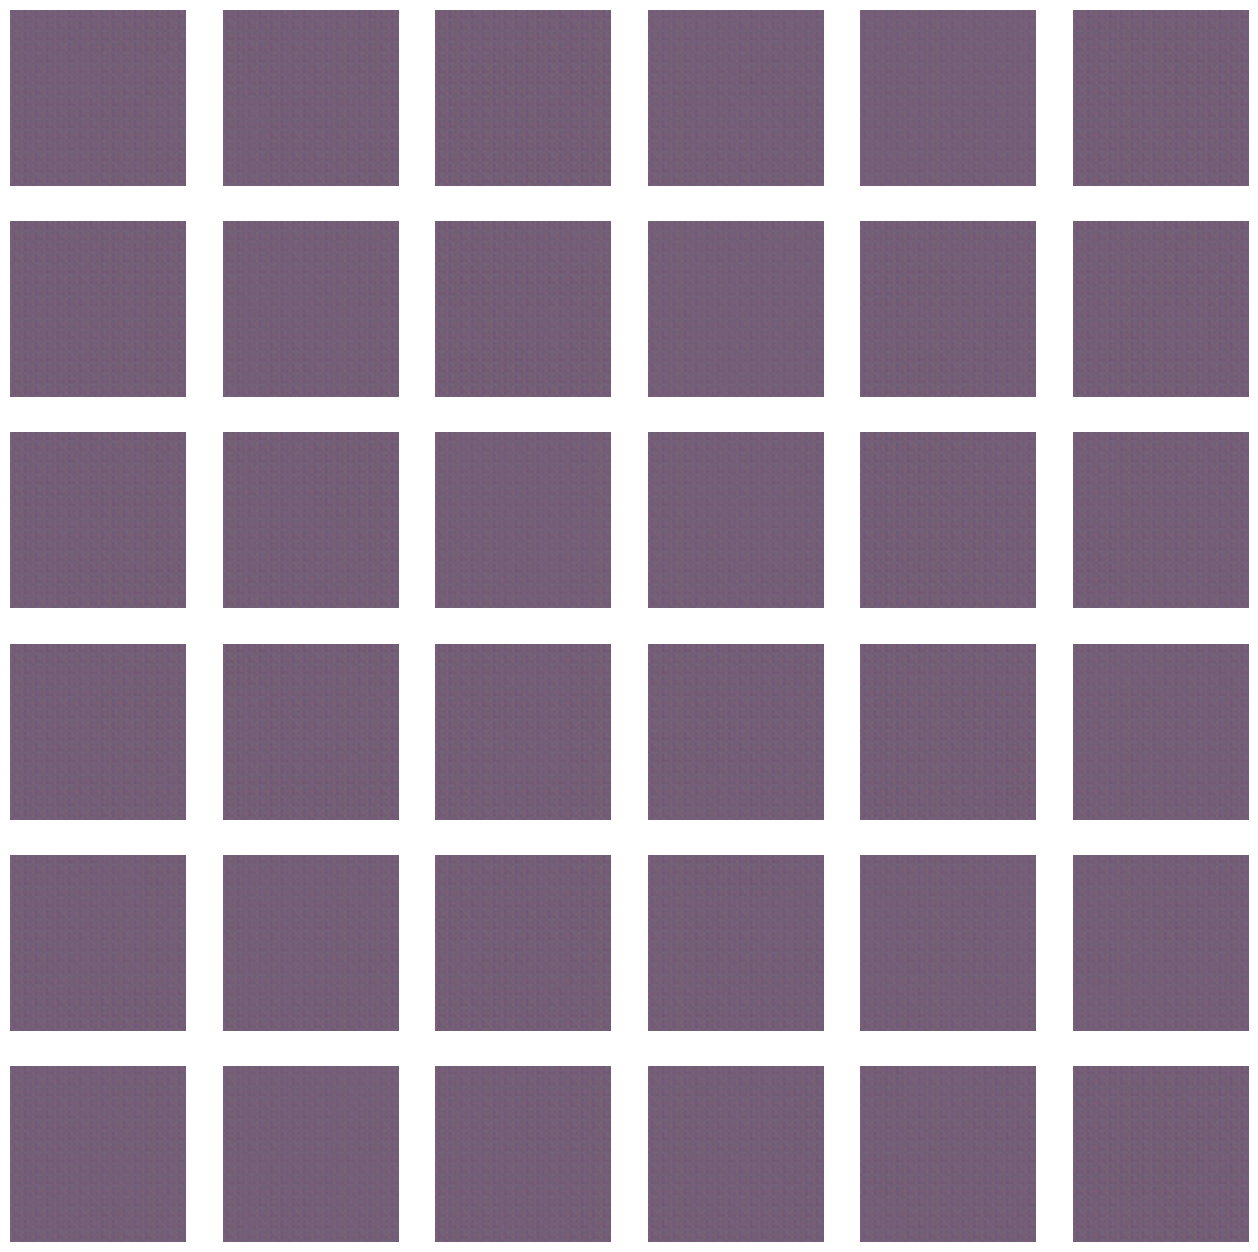

In [10]:
import matplotlib.pyplot as plt
visual()
fig = plt.gcf()
assert len(fig.axes) == 16